# Business KPI Analysis

## Objective

This notebook calculates important business KPIs from the Telco Customer Churn dataset.

These KPIs help management understand:

- Customer retention
- Revenue
- Churn impact
- Business growth
- Customer value

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/clean_telco.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
total_customers = df.shape[0]

print("Total Customers :", total_customers)

Total Customers : 7032


## KPI 1

Total number of customers available in the dataset.

In [5]:
churn_customers = df[df["Churn"] == "Yes"].shape[0]

print("Churn Customers :", churn_customers)

Churn Customers : 1869


In [6]:
active_customers = df[df["Churn"] == "No"].shape[0]

print("Active Customers :", active_customers)

Active Customers : 5163


In [7]:
churn_rate = (churn_customers / total_customers) * 100

print(f"Churn Rate : {churn_rate:.2f}%")

Churn Rate : 26.58%


Higher churn rate indicates customer dissatisfaction and business loss.

In [8]:
retention_rate = (active_customers / total_customers) * 100

print(f"Retention Rate : {retention_rate:.2f}%")

Retention Rate : 73.42%


In [9]:
average_monthly_revenue = df["MonthlyCharges"].mean()

print(f"Average Monthly Revenue : ${average_monthly_revenue:.2f}")

Average Monthly Revenue : $64.80


In [10]:
monthly_revenue = df["MonthlyCharges"].sum()

print(f"Total Monthly Revenue : ${monthly_revenue:.2f}")

Total Monthly Revenue : $455661.00


In [11]:
total_revenue = df["TotalCharges"].sum()

print(f"Total Revenue : ${total_revenue:.2f}")

Total Revenue : $16056168.70


In [12]:
revenue_lost = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

print(f"Revenue Lost : ${revenue_lost:.2f}")

Revenue Lost : $139130.85


This represents the recurring monthly revenue lost because churned customers are no longer paying.

In [13]:
average_tenure = df["tenure"].mean()

print(f"Average Tenure : {average_tenure:.2f} Months")

Average Tenure : 32.42 Months


In [14]:
clv = df["MonthlyCharges"].mean() * df["tenure"].mean()

print(f"Approx Customer Lifetime Value : ${clv:.2f}")

Approx Customer Lifetime Value : $2100.87


Approximate Customer Lifetime Value (CLV) is estimated as:

Average Monthly Charges × Average Tenure

In [15]:
contract_revenue = df.groupby("Contract")["MonthlyCharges"].sum()

contract_revenue

Contract
Month-to-month    257294.15
One year           95796.90
Two year          102569.95
Name: MonthlyCharges, dtype: float64

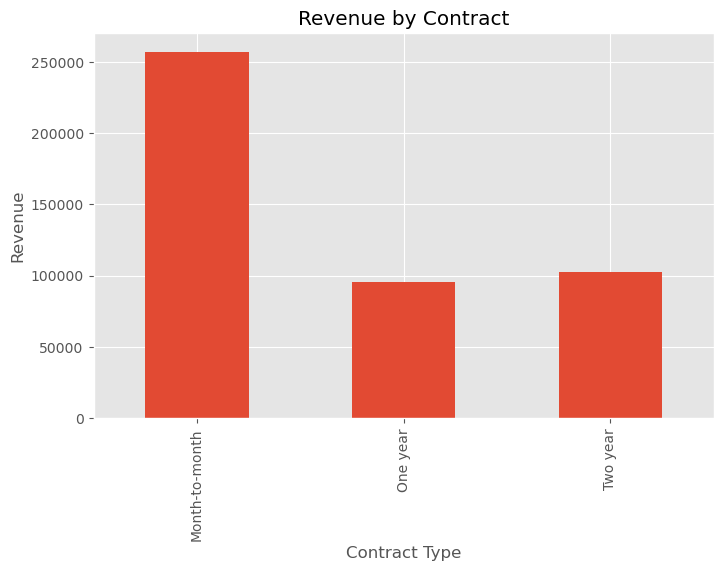

In [16]:
plt.figure(figsize=(8,5))

contract_revenue.plot(kind="bar")

plt.title("Revenue by Contract")

plt.ylabel("Revenue")

plt.xlabel("Contract Type")

plt.show()

In [17]:
internet_revenue = df.groupby("InternetService")["MonthlyCharges"].sum()

internet_revenue

InternetService
DSL            140340.65
Fiber optic    283284.40
No              32035.95
Name: MonthlyCharges, dtype: float64

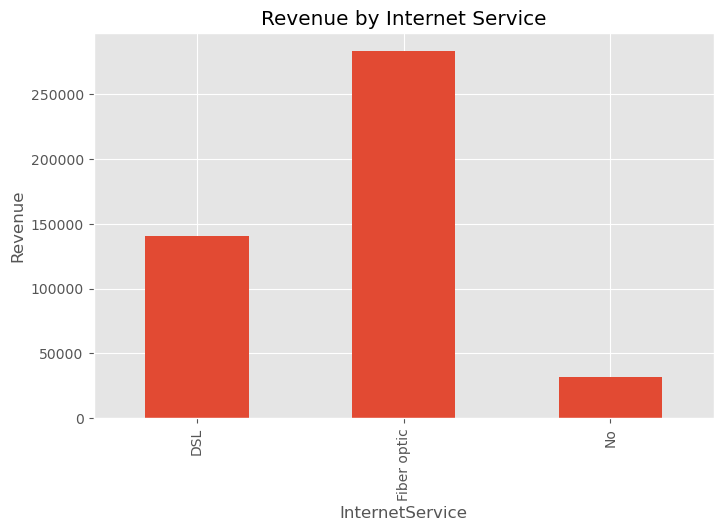

In [18]:
plt.figure(figsize=(8,5))

internet_revenue.plot(kind="bar")

plt.title("Revenue by Internet Service")

plt.ylabel("Revenue")

plt.show()

In [19]:
payment_revenue = df.groupby("PaymentMethod")["MonthlyCharges"].sum()

payment_revenue

PaymentMethod
Bank transfer (automatic)    103631.0
Credit card (automatic)      101175.8
Electronic check             180345.0
Mailed check                  70509.2
Name: MonthlyCharges, dtype: float64

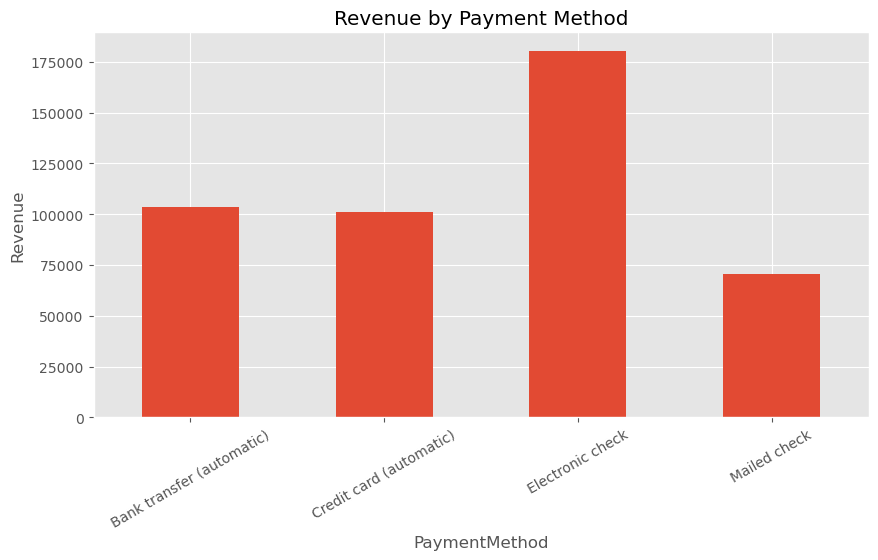

In [20]:
plt.figure(figsize=(10,5))

payment_revenue.plot(kind="bar")

plt.title("Revenue by Payment Method")

plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.show()

In [21]:
summary = pd.DataFrame({
    "KPI":[
        "Total Customers",
        "Active Customers",
        "Churn Customers",
        "Churn Rate",
        "Retention Rate",
        "Average Monthly Revenue",
        "Total Monthly Revenue",
        "Total Revenue",
        "Revenue Lost",
        "Average Tenure",
        "Approx CLV"
    ],

    "Value":[
        total_customers,
        active_customers,
        churn_customers,
        f"{churn_rate:.2f}%",
        f"{retention_rate:.2f}%",
        round(average_monthly_revenue,2),
        round(monthly_revenue,2),
        round(total_revenue,2),
        round(revenue_lost,2),
        round(average_tenure,2),
        round(clv,2)
    ]
})

summary

,KPI,Value
0,Total Customers,7032
1,Active Customers,5163
2,Churn Customers,1869
3,Churn Rate,26.58%
4,Retention Rate,73.42%
5,Average Monthly Revenue,64.8
6,Total Monthly Revenue,455661.0
7,Total Revenue,16056168.7
8,Revenue Lost,139130.85
9,Average Tenure,32.42


In [22]:
summary.to_csv("../data/business_kpis.csv", index=False)

print("Business KPIs exported successfully!")

Business KPIs exported successfully!


# Business Recommendations

1. Increase customer retention for Month-to-Month contracts.
2. Improve onboarding for new customers.
3. Provide attractive long-term contract discounts.
4. Reduce churn among Fiber Optic customers.
5. Improve technical support services.
6. Encourage Online Security adoption.
7. Offer loyalty rewards to long-tenure customers.
8. Reduce dependence on Electronic Check payment method.
9. Monitor customers with high monthly charges.
10. Build predictive models to identify high-risk customers.